In [ ]:
!pip install -U langchain langchain-openai openai`

In [ ]:
openai_key = #use your key :)
from langchain_openai import OpenAI

with openai
```python
model = 'meta/llama-3.1-8b-instruct'
prompt = 'Tell me a short fun fact about space.'

response = client.chat.completions.create(
    model=model,
    messages=[{'role': 'user', 'content': prompt}]
)
print(response.choice[0].message.content)
```


### with langchain
```python
base_url = os.getenv("NVIDIA_BASE_URL")
model = 'meta/llama-3.1-8b-instruct'
llm = ChatNVIDIA(base_url=base_url, model=model, temperature=0)
```

####**invoke**
```python
prompt = "how are the guys there"
response = llm.invoke(prompt).content # show the complete response after generating the whole response
```

####**uses of stream**
```python
response = llm.stream(prompt.content) # show response line by line while generating it

```
OR
```python
for chunk in llm.stream(prompt):
    print(chunk.content, end='')
```

####**Batch**

work with collection of data and return list of repsonses
```python
state_capital_questions = [
    'What is the capital of California?',
    'What is the capital of Texas?',
    'What is the capital of New York?',
    'What is the capital of Florida?',
    'What is the capital of Illinois?',
    'What is the capital of Ohio?'
]
capitals = llm.batch(state_capital_questions) # return a list of responses
for capital in capitals:
    print(capital.content)
```
### creating reusable prompts

####**Single Value**
```python
template = ChatPromptTemplate.from_template(""""Translate the following from English to Spanish. \
Provide only the translated text: {english_statement}""")

prompt = template.invoke("today is a good day"))
print(llm.envoke(prompt).content)
```
####**Multiple Values**
```python
lang1_to_lang2_translator = ChatPromptTemplate.from_template(""""Translate the following from {lang1} to {lange. \
Provide only the translated text: {statement}""")

prompt = lang1_to_lang2_translator.invoke({
  "lang1" : "English",
  "lang2" : "Arabic",
  "statment" : "will, i am happy that works will"
  })
print(llm.invoke(prompt).content)
```

# chains
<hr/>

### LCEL

langchain expression language is used to compose runnables into chains
```python
LcelTemplate = ChatPromptTemplate.from_template("Answer the following question: {question}")
chain_intro = LcelTemplate | llm
print(chain_intro.invoke({"question" : "how are you"}).content)
```
and i can parse the content of the output from llm by using an **output parser**
```python
parser = StrOutputParser()
chain_intro = LcelTemplate | llm | parser
print(chain_intro.invoke({"question" : "how are you"})
```
>*`print(chain.get_graph().draw_ascii())` use it when ever you want to see graphical preview of the chain*

>*sometimes you will need to prepare the input before puting it into the chain for any reason and for this use `RunnableLambda(func)` on the function that is used for preparing the text so you can put it into the chain*

####**runnables** : functions that accept methods of langchain such as `invoke() stream() batch()`

**chain of chains**

it's just idea of making a chain of long process of proccessing that contain multiple stages like preparing the input (stage 1) and generating the prompt output (stage2) but in it's core it's nothing more than `template/runnable | llm | parser` in any stage

####**Parallel Chains**

some tasks are indpenedent from each other or in other words cannot be in meaningful sequence so we here use `RunnableParallel('arbirtary name' : Runnable name)`
>*pay attention here that any function used there must be runnable first*
```python
parallel_chain = RunnableParallel({
  'length' : RunnableLambda(lambda x:len(x)),
  'captial' : RunnableLambda(lambda x: title(x)),
  'statment' : RunnableLambda(lambda x: {'text' : x})
})
```



# promping llm
<hr/>

```python
conversation_messages = ChatPromptTemplate.from_messages([
  ("human" : "hi"),
  ("ai" : "hello"),
  ("human" : '{prompt}') #if you edited this you should provide a place at the end so you can invoke the prompt in
])
```
*another way to write it*
```python
prompt_template = ChatPromptTemplate.from_messages([
    HumanMessage(content="Hello"),
    AIMessage(content="Hello, how are you?"),
    HumanMessage(content="{prompt}")
])
```
####**system messages**

this is more strong way to direct LLMs behaviour as it defines the role of LLM and In practice system messages can be quite large, very specific, and even contain example interactions (not as separate human and AI messages, but just written out).

and bellow you can find
<details>
<summary>few examples on system messages</summary>
<pre><code>
<ul>
<li>system_message_one = """\
You are a helpful assistant.

You have access to a `multiply` function that can be used on occasions when you have been requested to multiply two numbers.

Do not use the `mutiply` function by default! Only use it when explicitly asked to multiply two numbers!

You might be given numbers in your prompt, but this doesn't necessarily mean multiplication is required.

Example:

Input -> What year was the Declaration of Independence written?

Response -> The Declaration of Independence was written in 1776.


Note above example: NO TOOL CALL!!

Think hard about whether or not you need to use the `multiply` function and use it only when necessary!

Whether you use `multiply` function or simply respond with natural language (default behavior), send a helpful \
response to the user without mentioning any details about the tool use you may or may not have done.
"""
</li>

<li>system_message_two = """\
You are a helpful assistant capable of calling a `get_air_quality_category_for_location` \
tool calling when helpful, necessary, and appropriate.

Think hard about whether or not you need to call the `get_air_quality_category_for_location` tool, \
based on its description and use it, but only when appropriate!

You might be given locations in your prompt, but this doesn't necessarily mean getting the air quality is required.

Example:

Input -> What city is the capital of California?

Response -> Sacramento

Note above example: NO TOOL CALL!!

Whether or not you need to call a tool, address the user's query in a helpful informative way.

You should ALWAYS actually address the query and NEVER discuss your thought process about whether or not to use a tool.
"""
</li>
</ul>
</code></pre>
</details>

####**few-shot teqhnique**

we can use this to put some rules to our ai model using few-shot prompting teqhnique
```python
prompt_template = ChatPromptTemplate.from_messages([
    ("human", "hello"),
    ("ai", "HELLO"),
    ("human", "red"),
    ("ai", "RED"),
    ("human", "blue"),
    ("ai", "BLUE"),
    ("human", "{prompt}")
])

parser = StrOutputParser()
chain_fewshot = prompt_template | llm | parser
```
but it's not that strong it looks like as the following 2 examples fail
```python
chain_fewshot.invoke("invidia")
chain_fewshot.invoke("hi, how are you")
```
>*you should use multiple teqhniques in you prompting so that why fewshot alone looks week*

####**prompt message**

this also have a great effect of the llm output

####**chain of thoughts (CoT)**

chain of thoughts techinque is a way you give the llm methodology to go through in solving the problem and it can be extended with examples or just brief advice with zero-shot CoT

####**iterative prompting**

ofcourse it's a principle upon all the previous to iterate on the prompts them selves trying to make them more precise to give better outputs and save them in templates if needed

**placeholder message**

`MessagesPlaceholder` is a dynamic variable that tells the system: "I don't know exactly how many messages will be here yet, but when the time comes, dump the entire list of data here.

> take a list

> *this one is used to store some value and good one is to store the conversation histroy for more related next responses*
```python
template_with_placeholder = ChatPromptTemplate.from_messages([
    ('placeholder', '{messages}'),
    ('human', '{prompt}')
])

messages = [
    ('human', 'The sun came up today.'),
    ('ai', 'That is wonderful!'),
    ('human', 'The sun went down today.'),
    ('ai', 'That is also wonderful!.')
]

prompt = 'What happened today?'
template_with_placeholder.invoke({'message' : messages , 'prompt' : prompt})
```

<summery>some implementation details
<details>

```pythonclass ChatbotWithRole:
    def __init__(self, llm, system_message=''):
        # This is the same prompt template we used earlier, which a placeholder message for storing conversation history.
        chat_conversation_template = ChatPromptTemplate.from_messages([
            ('system', system_message),
            ('placeholder', '{chat_conversation}')
        ])

        # This is the same chain we created above, added to `self` for use by the `chat` method below.
        self.chat_chain = chat_conversation_template | llm | StrOutputParser()

        # Here we instantiate an empty list that will be added to over time.
        self.chat_conversation = []

    # `chat` expects a simple string prompt.
    def chat(self, prompt):
        # Append the prompt as a user message to chat conversation.
        self.chat_conversation.append(('user', prompt))
        
        response = self.chat_chain.invoke({'chat_conversation': self.chat_conversation})
        # Append the chain response as an `ai` message to chat conversation.
        self.chat_conversation.append(('ai', response))
        # Return the chain response to the user for viewing.
        return response

    # Clear conversation history.
    def clear(self):
        self.chat_conversation = []
```

</details></summery>

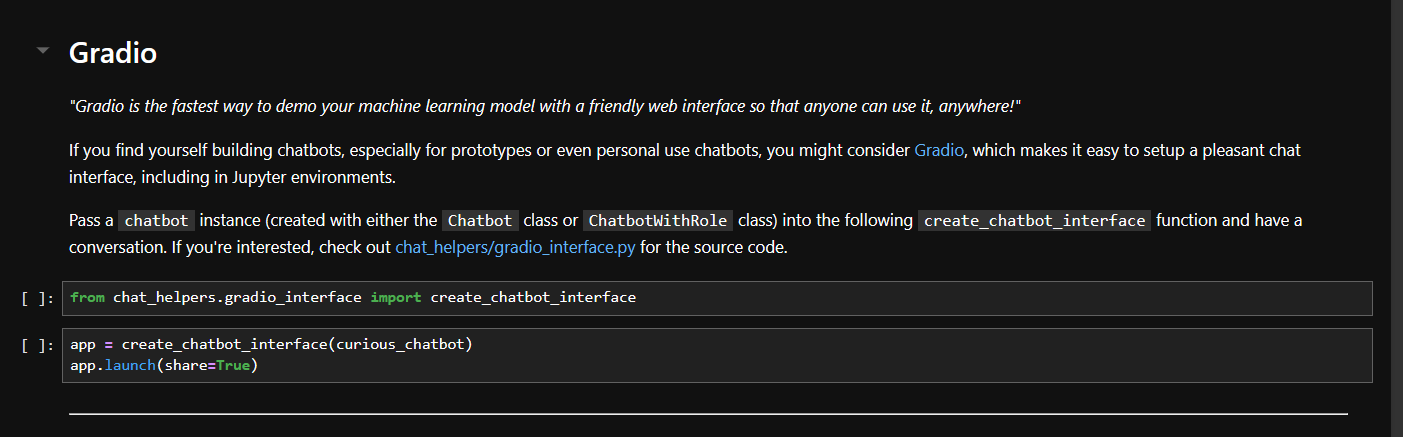

# structured output
<hr/>

to gerenate json output files problems here are:
- consistency in the names of the fields and datatypes of there values
- how to deal with absence of value

we here can use prompting:
- specific human prompt using **iterative prompting**
- using **system message** to set the rules for the llm
- using **few-shot** with examples from basic case and edge cases

**pydantic objects**
```python
class Book(BaseModel):
    """Information about a book."""

    title: str = Field(description="The title of the book")
    author: str = Field(description="The author of the book")
    year_of_publication: str = Field(description="The year the book was published")
```
we can use it to set rules for the llm to structure his response and parse only the json object
```python
parser = JsonOutputParser(pydantic_object = Book)
format_instructions = parser.ge_format_instructions()
# easy specific prompt
template = ChatPromptTemplate.from_messages([
    ("system", "You are an AI that generates JSON and only JSON according to the instructions provided to you."),
    ("human", (
        "Generate JSON about the user input according to the provided format instructions.\n" +
        "Input: {input}\n" +
        "Format instructions {format_instructions}")
    )
])

chain = template.partial(format_instructions = format_instructions) | llm | parser
chain.batch("any input)
```

<details>
<summary>side info</summary>
As an alternative, and improved way to generate structured output, many LLMs now support the with_structured_output method, which allows us to replace the following...
<pre>
<code>
template = ChatPromptTemplate.from_messages([
    ("system", "You are an AI that generates JSON and only JSON according to the instructions provided to you."),
    ("human", (
        "Generate JSON about the user input according to the provided format instructions.\n" +
        "Input: {input}\n" +
        "Format instructions {format_instructions}")
    )
])

chain = template.partial(format_instructions=format_instructions) | llm | JsonOutputParser(pydantic_object=Book)
... with:

llm_structured = llm.with_structured_output(Book)
</code></pre>

In the example just shown, llm_structured can be invoked, batched, or streamed just like chain, but the syntax is much more concise.

At the time of writing this (November 2024), the Llama 3.1b instruct NIM does not yet fully support the use of the with_structured_output method, but we expect it to be available very soon.
</details>

**lists of structured data**
```python
class list_book(BaseModel):
  """same instructions of book pydantic object but for multiple books"""
  books: list[book]
```

# tools
<ht/>

>we need tools? cause llm is just always predict the next word and this isn't suitable for somethings like math and can be improved in some others like getting true information in critical stuff

**agents**

to make a tool
```python
class Multiply(BaseModel):
    """Use when explicitly asked to multiply two integers together."""
    a: int = Field(..., description="First integer to multiply.")
    b: int = Field(..., description="Second integer to multiply.")

@tool(args_schema = Multiply)
def mulitply(a: int, b: int) -> int:
  return a*b

tools = [multiply]
agent = create_react_agent(llm , tools)
```

to give the agent a prompt:
```python
agent_state = agent.invoke({"messages": ["multiply 134 by 2525"]})
for message in agent_state['messages']:
    message.pretty_print()

# to simplify inputing
convert_to_agent_state = RunnableLambda(lambda prompt: {'messages': [prompt]})

#and to simplify output shape
agent_state_parser = RunnableLambda(lambda final_agent_state: final_agent_state['messages'][-1].content)
```
to graphically view the agent:
`display(Image(agent.get_graph().draw_mermaid_png()))`

we could try being more specific about when the agent ought to be using its tools by writing a longer more specific prompt, but since we are trying to impact the overarching behavior of the model, it might make more sense for us to try including a system message

>*in the next cell there are 2 sample for system messages*

how to include it:
```python
agent = create_react_agent(llm, tools=tools, state_modifier=system_message)
```
and to know more about the arguments of `create_react_agent` use `help(create_react_agent)`


